In [8]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import normalize 
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

In [9]:
data = pd.read_csv('Wholesale customers data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [10]:
data = np.log1p(data)
data = data.drop(['Channel' , 'Region' ] , axis = 1 )
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


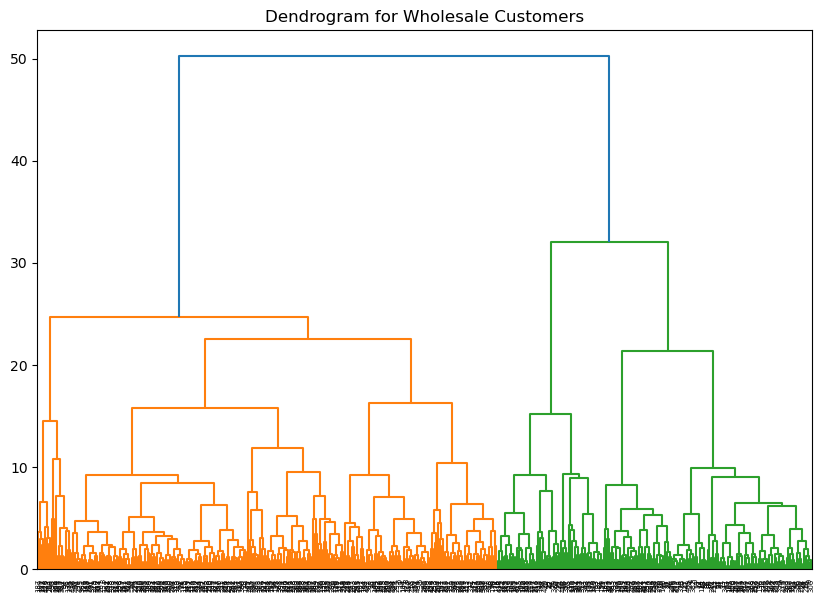

In [13]:
# 1. Create a figure with a specific size
plt.figure(figsize=(10, 7))  

# 2. Add a title to the plot
plt.title("Dendrogram for Wholesale Customers")  

# 3. Create the dendrogram using Ward's linkage method
dend = shc.dendrogram(shc.linkage(data_log, method='ward'))


plt.show()

In [17]:
from sklearn.metrics import silhouette_score
for k in range(2,10):
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(data)

    score = silhouette_score(data,labels)
    print(f"For n_clusters = {k}, the Silhouette Score is: {score:.4f}")
    

For n_clusters = 2, the Silhouette Score is: 0.2586
For n_clusters = 3, the Silhouette Score is: 0.2318
For n_clusters = 4, the Silhouette Score is: 0.2117
For n_clusters = 5, the Silhouette Score is: 0.1860
For n_clusters = 6, the Silhouette Score is: 0.2001
For n_clusters = 7, the Silhouette Score is: 0.1847
For n_clusters = 8, the Silhouette Score is: 0.1812
For n_clusters = 9, the Silhouette Score is: 0.1849


In [18]:
final_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
data['Cluster'] = final_model.fit_predict(data)

# 2. Calculate the average spending for each group to see who they are
# We exclude 'Channel' and 'Region' columns from the mean calculation
spending_profile = data.drop(['Channel', 'Region'], axis=1, errors='ignore').groupby('Cluster').mean()

print("--- FINAL CUSTOMER SEGMENTS PROFILE ---")
print(spending_profile.round(2))

--- FINAL CUSTOMER SEGMENTS PROFILE ---
         Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                            
0         8.63  8.81      9.2    7.03              8.02        6.82
1         8.84  7.36      7.6    7.61              5.42        6.50


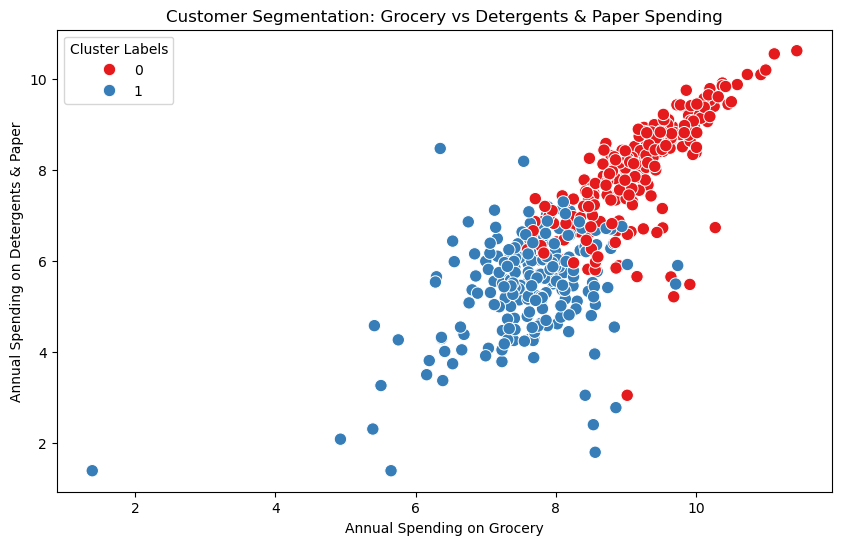

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Grocery', y='Detergents_Paper', hue='Cluster', data=data, palette='Set1', s=80)
plt.title('Customer Segmentation: Grocery vs Detergents & Paper Spending')
plt.xlabel('Annual Spending on Grocery')
plt.ylabel('Annual Spending on Detergents & Paper')
plt.legend(title='Cluster Labels')
plt.show()